In [173]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from tqdm import tqdm
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle

# POLITICAL COMPASS IMPLEMENTATION

Economic Axis: IndoBERT | Social Axis: mBERT

### 1. LOAD BOTH TRAINED MODELS

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

MAX_LEN = 64  # Same as training

Using device: cpu


In [3]:
print("\n1. Loading Economic Axis Model (IndoBERT - Left/Right)...")
tokenizer_economic = AutoTokenizer.from_pretrained('indolem/indobert-base-uncased')
model_economic = AutoModelForSequenceClassification.from_pretrained(
    'indolem/indobert-base-uncased',
    num_labels=2
)

model_economic.load_state_dict(torch.load('../x-axis/models/IndoBERT_economic_axis.pt', map_location=device))
model_economic.to(device)
model_economic.eval()
print("✓ Economic axis model loaded (IndoBERT)")


1. Loading Economic Axis Model (IndoBERT - Left/Right)...


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`
c:\Users\ASUS\anaconda3\envs\deep_learning\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS\.cache\huggingface\hub\models--indolem--indobert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, s

✓ Economic axis model loaded (IndoBERT)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


In [4]:
print("\n2. Loading Social Axis Model (mBERT - Authoritarian/Libertarian)...")
tokenizer_social = AutoTokenizer.from_pretrained('bert-base-multilingual-cased')
model_social = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-multilingual-cased',
    num_labels=2
)
model_social.load_state_dict(torch.load('../y-axis/models/mBERT_social_axis.pt', map_location=device))
model_social.to(device)
model_social.eval()
print("✓ Social axis model loaded (mBERT)")


2. Loading Social Axis Model (mBERT - Authoritarian/Libertarian)...


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Social axis model loaded (mBERT)


### 2. PREDICTION FUNCTION

In [119]:
def get_ideology_label(x, y):
    """Map coordinates to political ideology labels"""
    # Extreme positions
    if x < -0.6 and y > 0.6:
        return "Authoritarian Left"
    elif x > 0.6 and y > 0.6:
        return "Authoritarian Right"
    elif x < -0.6 and y < -0.6:
        return "Libertarian Left"
    elif x > 0.6 and y < -0.6:
        return "Libertarian Right"
    
    # Moderate positions
    elif x < -0.3 and y > 0.3:
        return "Left-Authoritarian"
    elif x > 0.3 and y > 0.3:
        return "Right-Authoritarian"
    elif x < -0.3 and y < -0.3:
        return "Left-Libertarian"
    elif x > 0.3 and y < -0.3:
        return "Right-Libertarian"
    
    # Center + edges
    elif abs(x) < 0.3 and abs(y) < 0.3:
        return "Centrist"
    elif abs(x) < 0.3:
        return "Authoritarian" if y > 0 else "Libertarian"
    elif abs(y) < 0.3:
        return "Left" if x < 0 else "Right"
    else:
        return "Mixed"

In [118]:
def predict_political_coordinates(text, model_econ, model_social, 
                                  tokenizer_econ, tokenizer_social, 
                                  device, max_len=64, method='hybrid'):
    """
    Predict (x, y) coordinates on political compass
    
    Returns:
        x (float): Economic position [-1=Left, +1=Right]
        y (float): Social position [-1=Libertarian, +1=Authoritarian]
    """
    
    # === ECONOMIC AXIS (X) ===
    inputs_econ = tokenizer_econ(
        text,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=max_len
    ).to(device)
    
    with torch.no_grad():
        outputs_econ = model_econ(**inputs_econ)
        logits_econ = outputs_econ.logits[0]
        probs_econ = torch.softmax(logits_econ, dim=0)
    
    # === SOCIAL AXIS (Y) ===
    inputs_social = tokenizer_social(
        text,
        return_tensors='pt',
        padding='max_length',
        truncation=True,
        max_length=max_len
    ).to(device)
    
    with torch.no_grad():
        outputs_social = model_social(**inputs_social)
        logits_social = outputs_social.logits[0]
        probs_social = torch.softmax(logits_social, dim=0)
    
    # === COORDINATE MAPPING ===
    if method == 'probability':
        # Method 1: Simple probability-based
        conf_econ = probs_econ.max().item()
        class_econ = probs_econ.argmax().item()
        mag_econ = (conf_econ - 0.5) * 2  # [0.5,1.0] → [0,1]
        x_coord = mag_econ if class_econ == 1 else -mag_econ
        
        conf_social = probs_social.max().item()
        class_social = probs_social.argmax().item()
        mag_social = (conf_social - 0.5) * 2
        y_coord = mag_social if class_social == 0 else -mag_social  # Note: 0=Auth, 1=Lib
        
    elif method == 'logits':
        # Method 2: Logit-based with tanh
        logit_diff_econ = (logits_econ[1] - logits_econ[0]).item()
        logit_diff_social = (logits_social[0] - logits_social[1]).item()  # Auth - Lib
        
        x_coord = np.tanh(logit_diff_econ / 4)
        y_coord = np.tanh(logit_diff_social / 4)
        
    else:  # 'hybrid' (RECOMMENDED)
        # Method 3: Hybrid approach
        conf_econ = probs_econ.max().item()
        class_econ = probs_econ.argmax().item()
        logit_diff_econ = abs(logits_econ[1] - logits_econ[0]).item()
        magnitude_econ = np.tanh(logit_diff_econ / 4)
        x_coord = magnitude_econ if class_econ == 1 else -magnitude_econ
        
        conf_social = probs_social.max().item()
        class_social = probs_social.argmax().item()
        logit_diff_social = abs(logits_social[0] - logits_social[1]).item()
        magnitude_social = np.tanh(logit_diff_social / 4)
        y_coord = magnitude_social if class_social == 0 else -magnitude_social
    
    # === METADATA ===
    econ_label = 'Right' if x_coord > 0 else 'Left'
    social_label = 'Authoritarian' if y_coord > 0 else 'Libertarian'
    ideology = get_ideology_label(x_coord, y_coord)
    
    return {
        'x': x_coord,
        'y': y_coord,
        'economic': econ_label,
        'social': social_label,
        'ideology': ideology,
        'econ_conf': probs_econ.max().item(),
        'social_conf': probs_social.max().item()
    }


In [120]:
def normalize_coordinates(coords_df, method='minmax'):
    """
    Normalize coordinates to use full [-1, +1] space
    Automatically handles edge cases:
    - Single data point
    - Small datasets
    - Uniform values (all same)
    - Normal large datasets
    
    Args:
        coords_df: DataFrame with 'x' and 'y' columns
        method: 'minmax' for linear scaling (only method needed)
    
    Returns:
        DataFrame with 'x_norm' and 'y_norm' columns added
    """
    
    n_points = len(coords_df)
    x_min, x_max = coords_df['x'].min(), coords_df['x'].max()
    y_min, y_max = coords_df['y'].min(), coords_df['y'].max()
    
    x_range = x_max - x_min
    y_range = y_max - y_min
    
    # CASE 1: Single data point or very small dataset (< 5 points)
    if n_points < 5:
        coords_df['x_norm'] = coords_df['x']
        coords_df['y_norm'] = coords_df['y']
        print(f"✓ Small dataset ({n_points} point{'s' if n_points > 1 else ''}) - using original coordinates")
        return coords_df
    
    # CASE 2: Small dataset (5-19 points) - normalize only if good spread
    if n_points < 20:
        # Only normalize if there's meaningful variation (range > 0.3)
        if x_range > 0.3 and y_range > 0.3:
            coords_df['x_norm'] = 2 * (coords_df['x'] - x_min) / x_range - 1
            coords_df['y_norm'] = 2 * (coords_df['y'] - y_min) / y_range - 1
            print(f"✓ Small dataset ({n_points} points) normalized - good spread detected")
        else:
            coords_df['x_norm'] = coords_df['x']
            coords_df['y_norm'] = coords_df['y']
            print(f"✓ Small dataset ({n_points} points) - insufficient spread, using original")
        return coords_df
    
    # CASE 3: Large dataset (20+ points) - apply normalization
    # Handle constant axes gracefully
    if x_range < 1e-10:  # X is constant
        coords_df['x_norm'] = coords_df['x']
        if y_range < 1e-10:  # Both constant
            coords_df['y_norm'] = coords_df['y']
            print(f"✓ All {n_points} points identical - using original coordinates")
        else:
            coords_df['y_norm'] = 2 * (coords_df['y'] - y_min) / y_range - 1
            print(f"✓ X constant at {x_min:.3f}, Y normalized [{y_min:.3f}, {y_max:.3f}] → [-1, +1]")
    elif y_range < 1e-10:  # Only Y is constant
        coords_df['x_norm'] = 2 * (coords_df['x'] - x_min) / x_range - 1
        coords_df['y_norm'] = coords_df['y']
        print(f"✓ Y constant at {y_min:.3f}, X normalized [{x_min:.3f}, {x_max:.3f}] → [-1, +1]")
    else:  # Normal case: both axes vary
        coords_df['x_norm'] = 2 * (coords_df['x'] - x_min) / x_range - 1
        coords_df['y_norm'] = 2 * (coords_df['y'] - y_min) / y_range - 1
        print(f"✓ Normalized {n_points} points:")
        print(f"  X: [{x_min:.3f}, {x_max:.3f}] → [-1.000, +1.000]")
        print(f"  Y: [{y_min:.3f}, {y_max:.3f}] → [-1.000, +1.000]")
    
    return coords_df


### 3. BATCH PREDICTION

In [121]:
def predict_dataset(texts, batch_size=32, method='hybrid'):
    """Predict coordinates for entire dataset with progress bar"""
    results = []
    
    print(f"\nPredicting coordinates for {len(texts)} texts...")
    print(f"Method: {method}")
    print(f"Batch size: {batch_size}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Processing batches"):
        batch_texts = texts[i:i+batch_size]
        
        for text in batch_texts:
            result = predict_political_coordinates(
                text,
                model_economic,
                model_social,
                tokenizer_economic,
                tokenizer_social,
                device,
                method=method
            )
            result['text'] = text[:100]  # Store first 100 chars
            results.append(result)
    
    return pd.DataFrame(results)

### 4. TEST ON SAMPLE TWEETS

In [122]:
sample_tweets = [
    # Left-Authoritarian
    "Negara must control ekonomi sepenuhnya untuk keadilan sosial",
    
    # Right-Authoritarian  
    "Pasar bebas bagus sihh tapi kyk perlu regulasi ketat dari gov buat stabilitas",
    
    # Left-Libertarian
    "Individual and economic freedom kolektif itu kunci masyarakat adil",
    
    # Right-Libertarian
    "Kurangi pajak, kurangi regulasi, biarin pasar sama individu bebas",
    
    # Centrist
    "Pemerintah dan swasta harus kolaborasi untuk kesejahteraan bersama",
    
    # Left leaning
    "Subsidi pendidikan dan kesehatan harus ditingkatkan untuk rakyat",
    
    # Right leaning
    "Investasi asing dan swasta penting untuk pertumbuhan ekonomi Indonesia",
]

In [174]:
print("\nTesting sample tweets:\n")

test_results = []
for i, tweet in enumerate(sample_tweets, 1):
    result = predict_political_coordinates(
        tweet,
        model_economic,
        model_social,
        tokenizer_economic,
        tokenizer_social,
        device,
        method='hybrid'
    )
    
    print(f"\n{i}. {tweet[:70]}...")
    print(f"   Position: ({result['x']:+.3f}, {result['y']:+.3f})")
    print(f"   Economic: {result['economic']} ({result['econ_conf']:.1%})")
    print(f"   Social: {result['social']} ({result['social_conf']:.1%})")
    print(f"   Ideology: {result['ideology']}")
    
    test_results.append(result)


Testing sample tweets:


1. Negara must control ekonomi sepenuhnya untuk keadilan sosial...
   Position: (+0.391, -0.121)
   Economic: Right (83.9%)
   Social: Libertarian (62.0%)
   Ideology: Right

2. Pasar bebas bagus sihh tapi kyk perlu regulasi ketat dari gov buat sta...
   Position: (-0.504, -0.524)
   Economic: Left (90.2%)
   Social: Libertarian (91.1%)
   Ideology: Left-Libertarian

3. Individual and economic freedom kolektif itu kunci masyarakat adil...
   Position: (+0.676, -0.067)
   Economic: Right (96.4%)
   Social: Libertarian (56.7%)
   Ideology: Right

4. Kurangi pajak, kurangi regulasi, biarin pasar sama individu bebas...
   Position: (-0.805, -0.507)
   Economic: Left (98.9%)
   Social: Libertarian (90.4%)
   Ideology: Left-Libertarian

5. Pemerintah dan swasta harus kolaborasi untuk kesejahteraan bersama...
   Position: (+0.305, +0.270)
   Economic: Right (77.9%)
   Social: Authoritarian (75.2%)
   Ideology: Right

6. Subsidi pendidikan dan kesehatan harus ditingka

### 5. VISUALIZATION FUNCTIONS

In [334]:
def plot_political_compass(coords_df, title="Indonesian Political Compass", 
                           figsize=(18, 8), save_path=None, use_normalized=False):
    """
    Political compass with quadrant-based colors
    - Auth Left: Red shades
    - Auth Right: Blue shades  
    - Lib Left: Green shades
    - Lib Right: Purple shades
    Intensity increases with distance from center
    """
    
    x_col = 'x_norm' if use_normalized and 'x_norm' in coords_df.columns else 'x'
    y_col = 'y_norm' if use_normalized and 'y_norm' in coords_df.columns else 'y'
    
    # Calculate colors based on quadrant and distance from center
    def get_point_color(x, y):
        """Return color based on position"""
        # Calculate distance from center (for intensity)
        distance = np.sqrt(x**2 + y**2) / np.sqrt(2)  # Normalize to [0, 1]
        
        # Base colors for each quadrant
        if x < 0 and y > 0:  # Auth Left
            base_color = np.array([0.8, 0.0, 0.0])  # Red
        elif x >= 0 and y > 0:  # Auth Right
            base_color = np.array([0.0, 0.0, 0.8])  # Blue
        elif x < 0 and y <= 0:  # Lib Left
            base_color = np.array([0.0, 0.6, 0.0])  # Green
        else:  # Lib Right
            base_color = np.array([0.5, 0.0, 0.5])  # Purple
        
        # Interpolate between white (center) and base color (edge)
        white = np.array([1.0, 1.0, 1.0])
        color = white * (1 - distance * 0.8) + base_color * (distance * 0.8)
        
        return color
    
    # Generate colors for all points
    colors = [get_point_color(row[x_col], row[y_col]) 
              for _, row in coords_df.iterrows()]
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # === PLOT 1: SCATTER WITH QUADRANT COLORS ===
    ax1 = axes[0]
    
    scatter = ax1.scatter(
        coords_df[x_col], 
        coords_df[y_col],
        c=colors,
        s=80,
        alpha=0.7,
        edgecolors='black',
        linewidth=0.8
    )
    
    # Add quadrant backgrounds (subtle)
    ax1.add_patch(Rectangle((-1.05, 0), 1.05, 1.05, 
                            facecolor='red', alpha=0.05, zorder=0))
    ax1.add_patch(Rectangle((0, 0), 1.05, 1.05, 
                            facecolor='blue', alpha=0.05, zorder=0))
    ax1.add_patch(Rectangle((-1.05, -1.05), 1.05, 1.05, 
                            facecolor='green', alpha=0.05, zorder=0))
    ax1.add_patch(Rectangle((0, -1.05), 1.05, 1.05, 
                            facecolor='purple', alpha=0.05, zorder=0))
    
    # Quadrant lines
    ax1.axhline(0, color='black', linewidth=2.5, linestyle='-', alpha=0.8, zorder=1)
    ax1.axvline(0, color='black', linewidth=2.5, linestyle='-', alpha=0.8, zorder=1)
    
    # Quadrant labels
    bbox_props = dict(boxstyle='round,pad=0.6', facecolor='white', 
                     edgecolor='black', alpha=0.9, linewidth=2)
    
    ax1.text(-1, 1.25, 'AUTHORITARIAN\nLEFT', ha='center', va='center',
            fontsize=11, weight='bold', bbox=bbox_props, color='darkred')
    ax1.text(1, 1.25, 'AUTHORITARIAN\nRIGHT', ha='center', va='center',
            fontsize=11, weight='bold', bbox=bbox_props, color='darkblue')
    ax1.text(-1, -1.3, 'LIBERTARIAN\nLEFT', ha='center', va='center',
            fontsize=11, weight='bold', bbox=bbox_props, color='darkgreen')
    ax1.text(1, -1.3, 'LIBERTARIAN\nRIGHT', ha='center', va='center',
            fontsize=11, weight='bold', bbox=bbox_props, color='purple')
    
    ax1.set_xlim(-1.1, 1.1)
    ax1.set_ylim(-1.1, 1.1)
    ax1.set_xlabel('Economic Axis: LEFT ← → RIGHT', fontsize=13, weight='bold')
    ax1.set_ylabel('Social Axis: LIBERTARIAN ← → AUTHORITARIAN', 
                   fontsize=13, weight='bold')
    ax1.set_title('Scatter Plot (Quadrant Colors)', fontsize=14, weight='bold')
    ax1.grid(True, alpha=0.2, linestyle=':', color='gray')
    ax1.set_facecolor('#fafafa')
    
    # === PLOT 2: DENSITY HEATMAP ===
    ax2 = axes[1]
    
    hb = ax2.hexbin(
        coords_df[x_col],
        coords_df[y_col],
        gridsize=35,
        cmap='YlOrRd',
        mincnt=1,
        edgecolors='gray',
        linewidths=0.2,
        alpha=0.85
    )
    
    # Quadrant lines
    ax2.axhline(0, color='black', linewidth=2.5, linestyle='-', alpha=0.8)
    ax2.axvline(0, color='black', linewidth=2.5, linestyle='-', alpha=0.8)
    
    # Quadrant labels
    ax2.text(-1, 1.2, 'AUTH\nLEFT', ha='center', fontsize=11, weight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.4', 
            facecolor='black', alpha=0.7, edgecolor='white', linewidth=1.5))
    ax2.text(1, 1.2, 'AUTH\nRIGHT', ha='center', fontsize=11, weight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.4', 
            facecolor='black', alpha=0.7, edgecolor='white', linewidth=1.5))
    ax2.text(-1, -1.35, 'LIB\nLEFT', ha='center', fontsize=11, weight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.4', 
            facecolor='black', alpha=0.7, edgecolor='white', linewidth=1.5))
    ax2.text(1, -1.35, 'LIB\nRIGHT', ha='center', fontsize=11, weight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.4', 
            facecolor='black', alpha=0.7, edgecolor='white', linewidth=1.5))
    
    ax2.set_xlim(-1.1, 1.1)
    ax2.set_ylim(-1.1, 1.1)
    ax2.set_xlabel('Economic Axis: LEFT ← → RIGHT', fontsize=13, weight='bold')
    ax2.set_ylabel('Social Axis: LIBERTARIAN ← → AUTHORITARIAN', 
                   fontsize=13, weight='bold')
    ax2.set_title('Density Heatmap', fontsize=14, weight='bold')
    ax2.grid(True, alpha=0.2, linestyle=':', color='gray')
    ax2.set_facecolor('#fafafa')
    
    cbar2 = plt.colorbar(hb, ax=ax2, pad=0.02)
    cbar2.set_label('Number of Posts', fontsize=11, weight='bold')
    
    # Main title
    plt.suptitle(title, fontsize=17, weight='bold', y=0.98)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"✓ Saved to {save_path}")
    
    plt.show()



In [335]:
def plot_ideology_distribution(coords_df, top_n=10):
    """Plot distribution of ideologies"""
    ideology_counts = coords_df['ideology'].value_counts().head(top_n)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(ideology_counts)))
    bars = ax.barh(ideology_counts.index, ideology_counts.values, 
                   color=colors, edgecolor='black', linewidth=1.5)
    
    ax.set_xlabel('Number of Posts', fontsize=13, weight='bold')
    ax.set_ylabel('Political Ideology', fontsize=13, weight='bold')
    ax.set_title(f'Top {top_n} Political Ideologies in Dataset', 
                 fontsize=15, weight='bold')
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()
    
    # Add value labels
    for i, (idx, count) in enumerate(ideology_counts.items()):
        ax.text(count + max(ideology_counts) * 0.01, i, 
                f'{count:,}', va='center', fontsize=11, weight='bold')
    
    plt.tight_layout()
    plt.show()


In [336]:
def plot_quadrant_distribution(coords_df, use_normalized=False):
    """Plot distribution across quadrants"""
    x_col = 'x_norm' if use_normalized and 'x_norm' in coords_df.columns else 'x'
    y_col = 'y_norm' if use_normalized and 'y_norm' in coords_df.columns else 'y'
    
    def get_quadrant(row):
        if row[x_col] >= 0 and row[y_col] >= 0:
            return 'Auth Right'
        elif row[x_col] < 0 and row[y_col] >= 0:
            return 'Auth Left'
        elif row[x_col] < 0 and row[y_col] < 0:
            return 'Lib Left'
        else:
            return 'Lib Right'
    
    coords_df['quadrant'] = coords_df.apply(get_quadrant, axis=1)
    quadrant_counts = coords_df['quadrant'].value_counts()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Bar chart
    colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
    quadrant_counts.plot(kind='bar', ax=ax1, color=colors, 
                         edgecolor='black', linewidth=2)
    ax1.set_xlabel('Quadrant', fontsize=13, weight='bold')
    ax1.set_ylabel('Number of Posts', fontsize=13, weight='bold')
    ax1.set_title('Posts per Quadrant', fontsize=15, weight='bold')
    ax1.grid(axis='y', alpha=0.3)
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
    
    # Add percentages
    total = quadrant_counts.sum()
    for i, (quad, count) in enumerate(quadrant_counts.items()):
        pct = (count / total) * 100
        ax1.text(i, count, f'{count}\n({pct:.1f}%)', 
                ha='center', va='bottom', fontsize=11, weight='bold')
    
    # Pie chart
    ax2.pie(quadrant_counts.values, labels=quadrant_counts.index, 
           autopct='%1.1f%%', colors=colors, startangle=90,
           textprops={'fontsize': 12, 'weight': 'bold'},
           wedgeprops={'edgecolor': 'black', 'linewidth': 2})
    ax2.set_title('Quadrant Distribution', fontsize=15, weight='bold')
    
    plt.tight_layout()
    plt.show()


### 6. SUMMARY STATISTICS

In [337]:
def print_compass_statistics(coords_df):
    """Print comprehensive statistics"""
    print("\n" + "="*80)
    print("POLITICAL COMPASS STATISTICS")
    print("="*80)
    
    print(f"\nTotal posts analyzed: {len(coords_df):,}")
    
    print("\n--- COORDINATE STATISTICS ---")
    print(f"Economic Axis (X):")
    print(f"  Mean: {coords_df['x'].mean():+.3f}")
    print(f"  Median: {coords_df['x'].median():+.3f}")
    print(f"  Std Dev: {coords_df['x'].std():.3f}")
    print(f"  Range: [{coords_df['x'].min():+.3f}, {coords_df['x'].max():+.3f}]")
    
    print(f"\nSocial Axis (Y):")
    print(f"  Mean: {coords_df['y'].mean():+.3f}")
    print(f"  Median: {coords_df['y'].median():+.3f}")
    print(f"  Std Dev: {coords_df['y'].std():.3f}")
    print(f"  Range: [{coords_df['y'].min():+.3f}, {coords_df['y'].max():+.3f}]")
    
    print("\n--- QUADRANT DISTRIBUTION ---")
    coords_df['quadrant'] = coords_df.apply(
        lambda r: 'Auth Right' if r['x'] >= 0 and r['y'] >= 0
        else 'Auth Left' if r['x'] < 0 and r['y'] >= 0
        else 'Lib Left' if r['x'] < 0 and r['y'] < 0
        else 'Lib Right', axis=1
    )
    
    for quad, count in coords_df['quadrant'].value_counts().items():
        pct = (count / len(coords_df)) * 100
        print(f"  {quad}: {count:,} ({pct:.1f}%)")
    
    print("\n--- TOP 5 IDEOLOGIES ---")
    for ideology, count in coords_df['ideology'].value_counts().head(5).items():
        pct = (count / len(coords_df)) * 100
        print(f"  {ideology}: {count:,} ({pct:.1f}%)")
    
    print("\n" + "="*80)


### 7. Test using Dataset

In [338]:
df = pd.read_csv('../../Datasets/y-axis/MITweet_Translated_Slang.csv')

In [339]:
df.head()

,tweet,label,tweet_translated
0,Forget about protecting the people and communi...,1,they Lupakan supposed continue tentang melindu...
1,Are you with an #environmentalnonprofit leadin...,0,Apakah lu dengan and #environmentalnonprofit w...
2,Curious if #IRA can help you electrify your ho...,1,Penasaran apakah #IRA bisa handy INCREDIBLE me...
3,Learn more from \n on how huge investments fro...,0,& Pelajari lebih transitions lanjut dari pada ...
4,Almost a year since this Vox video on grid cha...,1,Hampir setahun sejak Vox curtain video Vox di ...


In [340]:
texts = df['tweet_translated'].tolist()

In [348]:
coords_df = predict_dataset(texts[:1000], batch_size=32, method='hybrid')


Predicting coordinates for 1000 texts...
Method: hybrid
Batch size: 32


Processing batches: 100%|██████████| 32/32 [02:53<00:00,  5.43s/it]


In [349]:
coords_df = normalize_coordinates(coords_df, method='minmax')

✓ Normalized 1000 points:
  X: [-0.701, 0.743] → [-1.000, +1.000]
  Y: [-0.626, 0.613] → [-1.000, +1.000]


✓ Saved to political_compass.png


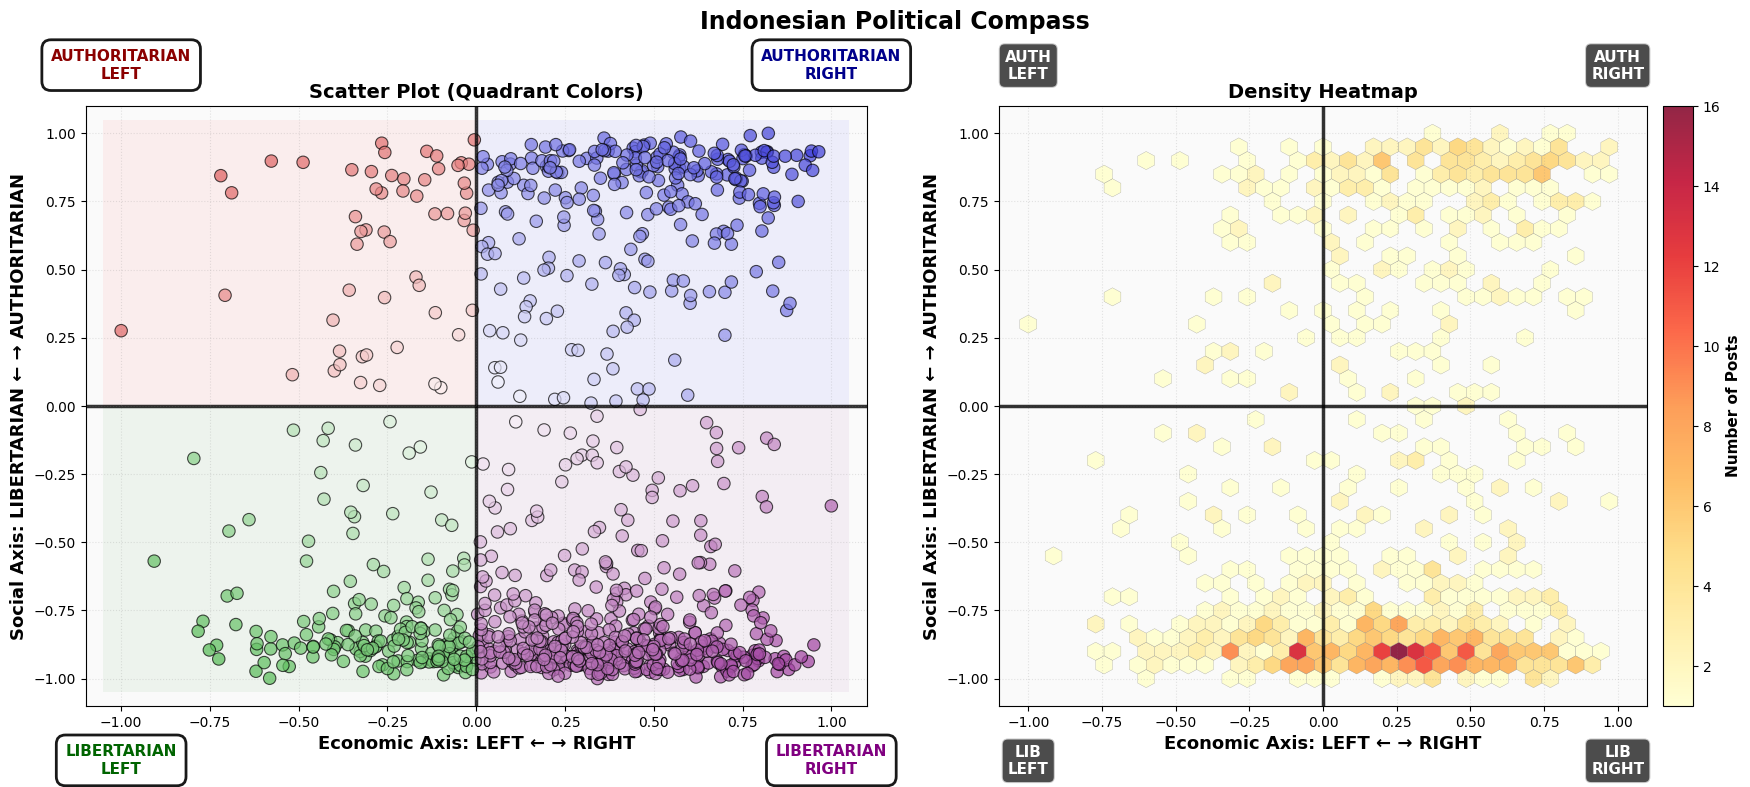

In [350]:
plot_political_compass(coords_df, save_path='political_compass.png', use_normalized=True)

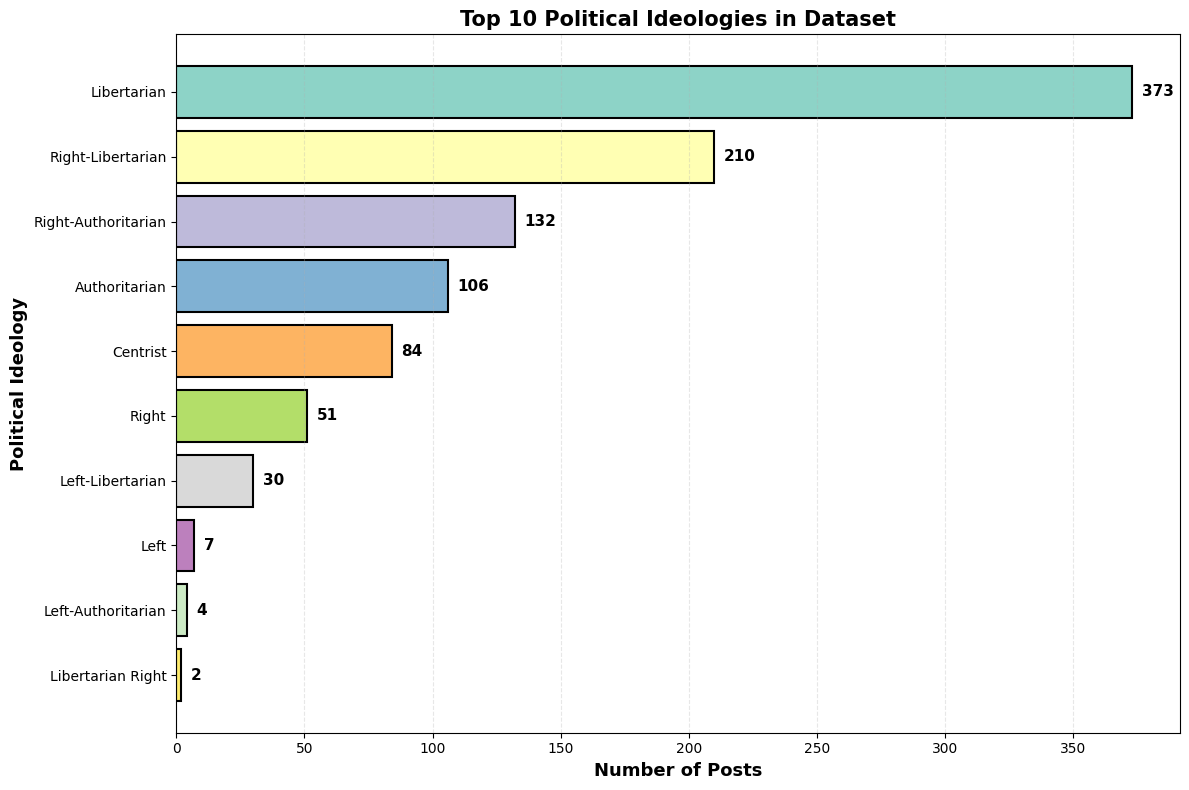

In [351]:
plot_ideology_distribution(coords_df)

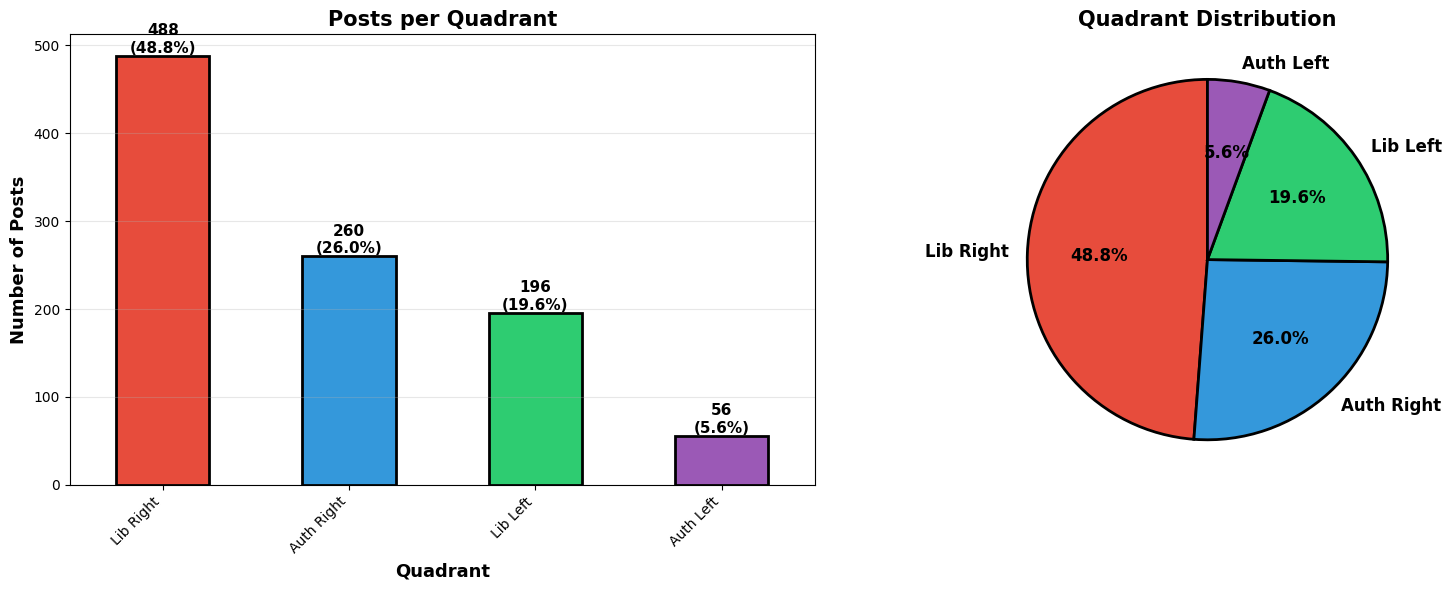

In [352]:
plot_quadrant_distribution(coords_df, use_normalized=True)


In [353]:
print_compass_statistics(coords_df)


POLITICAL COMPASS STATISTICS

Total posts analyzed: 1,000

--- COORDINATE STATISTICS ---
Economic Axis (X):
  Mean: +0.199
  Median: +0.226
  Std Dev: 0.271
  Range: [-0.701, +0.743]

Social Axis (Y):
  Mean: -0.207
  Median: -0.487
  Std Dev: 0.451
  Range: [-0.626, +0.613]

--- QUADRANT DISTRIBUTION ---
  Lib Right: 499 (49.9%)
  Auth Right: 265 (26.5%)
  Lib Left: 185 (18.5%)
  Auth Left: 51 (5.1%)

--- TOP 5 IDEOLOGIES ---
  Libertarian: 373 (37.3%)
  Right-Libertarian: 210 (21.0%)
  Right-Authoritarian: 132 (13.2%)
  Authoritarian: 106 (10.6%)
  Centrist: 84 (8.4%)

